# Two-stage XGBoost evaluation — excluding always-100%-funnel-entry sites

**Recovery framing.** "Recovery" in this dataset refers to a unit *entering the recovery funnel* (recycling / donation / disposal) instead of being sold through the normal channel. **A higher recovery rate is a worse business outcome** — it means more inventory ended up unsellable. We therefore frame the analysis as:
  - high `prob_recovered` = bad (more units flowed into the funnel),
  - deviation **above** the long-run baseline = the model expects this week to be *worse* than usual,
  - deviation **below** the long-run baseline = better than usual.

Plot colour convention: **red = pushed up (worse than baseline)**, **green = pulled down (better than baseline)**.

Loads the two-stage models tuned on the subset of aggregated data that excludes fulfillment sites whose funnel-entry rate is consistently 1.0, runs inference on the 2025 test slice using **Approach A only** (`pred_prob = p_nonzero * e_rate`), and produces stakeholder-oriented diagnostics:

1. Overall + bucket-stratified MAE for both stages and the combined model.
2. Global SHAP beeswarm for Stage 1 and Stage 2.
3. Stage 2 baseline-vs-deviation decomposition — separating "what this site/GL usually does" from "what changed this week" — with stakeholder visualisations.
4. Top funnel-entry sites and top funnel-entry GLs, monthly actual vs predicted.


In [1]:
!pip install shap polars

In [2]:
import logging
import tempfile
import time

import boto3
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import shap
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier, XGBRegressor

pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(15)
pd.set_option("display.max_columns", 50)

In [3]:
def save_model_to_s3(model, bucket_name, object_key):
    s3_client = boto3.client('s3')
    try:
        with tempfile.TemporaryFile() as fp:
            joblib.dump(model, fp)
            fp.seek(0)
            s3_client.put_object(Body=fp.read(), Bucket=bucket_name, Key=object_key)
            logging.info(f'{object_key} saved to s3 bucket {bucket_name}')
    except Exception as e:
        logging.exception(e)
        raise


def load_model_from_s3(bucket_name, object_key):
    s3_client = boto3.client('s3')
    try:
        with tempfile.TemporaryFile() as fp:
            s3_client.download_fileobj(bucket_name, object_key, fp)
            fp.seek(0)
            model = joblib.load(fp)
            logging.info(f'{object_key} loaded from s3 bucket {bucket_name}')
            return model
    except Exception as e:
        logging.exception(e)
        raise

## Load data + train/test split

In [4]:
df = pl.read_parquet(
    "s3://msds-26.2-data/clean/combined_recovery_data_aggregated_with_full_features_excluding_full_recovery_site.parquet"
)
df_train = df.filter(pl.col("year") < 2025)
df_test  = df.filter(pl.col("year") == 2025)
print(f"train rows: {len(df_train):,}    test rows: {len(df_test):,}")
print(f"unique sites in test: {df_test['hashed_fc'].n_unique():,}")
print(f"unique GLs in test:   {df_test['gl_product_group'].n_unique():,}")


train rows: 5,965,924    test rows: 2,459,660
unique sites in test: 14,902
unique GLs in test:   139


## Feature lists

Copied verbatim from `xgboost_classification_regression_excluding_full_recovery.ipynb` — must stay in sync or model loading silently produces wrong predictions.

In [5]:
# Define features and target variable
identity_cols = [
    "hashed_fc", "gl_product_group", "week_date",
]

gl_composition_cols = [
    "share_food", "share_non_food", "share_pet_food",
    "share_RETAIL", "share_FBA", "share_hazmat",
]

gl_volume_cols = [
    "units_total", "cogs_total", "weight_total",
    "avg_cogs_per_unit", "avg_weight_per_unit", "cogs_per_unit_weight",
]

gl_at_site_cols = [
    "site_units_share_week", "site_weight_share_week",
]

site_context_cols = [
    "site_units_total_week", "site_weight_total_week",
    "site_type", "site_category", "country", "country_state",
]

temporal_site_context_cols = ['site_units_total_week_lag_1w',
 'site_units_total_week_lag_4w',
 'site_units_total_week_lag_12w',
 'site_units_total_week_lag_13w',
 'site_units_total_week_lag_52w',
 'site_weight_total_week_lag_1w',
 'site_weight_total_week_lag_4w',
 'site_weight_total_week_lag_12w',
 'site_weight_total_week_lag_13w',
 'site_weight_total_week_lag_52w',
 'site_prob_recovered_week_lag_1w',
 'site_prob_recovered_week_lag_4w',
 'site_prob_recovered_week_lag_12w',
 'site_prob_recovered_week_lag_13w',
 'site_prob_recovered_week_lag_52w',
 'site_prob_recovered_week_rolling_4w',
 'site_prob_recovered_week_rolling_12w',
'site_prob_recovered_week_rolling_26w',
 'site_prob_recovered_week_rolling_52w',
]

calendar_cols = [
    "month", "week"
]

temporal_composition_cols = [
 'share_RETAIL_lag_1w',
 'share_RETAIL_lag_4w',
 'share_RETAIL_lag_12w',
 'share_RETAIL_lag_13w',
 'share_RETAIL_lag_52w',
 'share_FBA_lag_4w',
 'share_FBA_lag_12w',
 'share_FBA_lag_13w',
 'share_FBA_lag_52w',
 'share_hazmat_lag_1w',
 'share_hazmat_lag_4w',
 'share_hazmat_lag_12w',
 'share_hazmat_lag_13w',
 'share_hazmat_lag_52w',
 'share_food_lag_1w',
 'share_food_lag_4w',
 'share_food_lag_12w',
 'share_food_lag_13w',
 'share_food_lag_52w',
 'share_non_food_lag_1w',
 'share_non_food_lag_4w',
 'share_non_food_lag_12w',
 'share_non_food_lag_13w',
 'share_non_food_lag_52w',
 'share_pet_food_lag_1w',
 'share_pet_food_lag_4w',
 'share_pet_food_lag_12w',
 'share_pet_food_lag_13w',
 'share_pet_food_lag_52w',
 'share_food_rolling_4w',
 'share_food_rolling_12w',
 'share_non_food_rolling_4w',
 'share_non_food_rolling_12w',
 'share_pet_food_rolling_4w',
 'share_pet_food_rolling_12w',
 'share_RETAIL_rolling_4w',
 'share_RETAIL_rolling_12w',
 'share_FBA_rolling_4w',
 'share_FBA_rolling_12w',
 'share_hazmat_rolling_4w',
 'share_hazmat_rolling_12w',
 'share_food_rolling_26w',
 'share_food_rolling_52w',
 'share_non_food_rolling_26w',
 'share_non_food_rolling_52w',
 'share_pet_food_rolling_26w',
 'share_pet_food_rolling_52w',
 'share_RETAIL_rolling_26w',
 'share_RETAIL_rolling_52w',
 'share_FBA_rolling_26w',
 'share_FBA_rolling_52w',
 'share_hazmat_rolling_26w',
 'share_hazmat_rolling_52w',
 'share_RETAIL_ewma_5a',
 'share_RETAIL_ewma_1a',
 'share_FBA_ewma_5a',
 'share_FBA_ewma_1a',
 'share_hazmat_ewma_5a',
 'share_hazmat_ewma_1a',
 'share_food_ewma_5a',
 'share_food_ewma_1a',
 'share_non_food_ewma_5a',
 'share_non_food_ewma_1a',
 'share_pet_food_ewma_5a',
 'share_pet_food_ewma_1a',
]

temporal_volume_cols = [
 'units_total_lag_1w',
 'units_total_lag_4w',
 'units_total_lag_12w',
 'units_total_lag_13w',
 'units_total_lag_52w',
 'cogs_total_lag_1w',
 'cogs_total_lag_4w',
 'cogs_total_lag_12w',
 'cogs_total_lag_13w',
 'cogs_total_lag_52w',
 'weight_total_lag_1w',
 'weight_total_lag_4w',
 'weight_total_lag_12w',
 'weight_total_lag_13w',
 'weight_total_lag_52w',
 'units_total_rolling_4w',
 'units_total_rolling_12w',
 'cogs_total_rolling_4w',
 'cogs_total_rolling_12w',
 'weight_total_rolling_4w',
 'weight_total_rolling_12w',
 'units_total_rolling_26w',
 'units_total_rolling_52w',
 'cogs_total_rolling_26w',
 'cogs_total_rolling_52w',
 'weight_total_rolling_26w',
 'weight_total_rolling_52w',
 'units_total_ewma_5a',
 'units_total_ewma_1a',
 'cogs_total_ewma_5a',
 'cogs_total_ewma_1a',
 'weight_total_ewma_5a',
 'weight_total_ewma_1a'
]

temporal_probability_cols = [
 'prob_recovered_lag_1w',
 'prob_recovered_lag_4w',
 'prob_recovered_lag_12w',
 'prob_recovered_lag_13w',
 'prob_recovered_lag_52w',
 'prob_recovered_rolling_26w',
 'prob_recovered_rolling_52w',
 'prob_recovered_rolling_4w',
 'prob_recovered_rolling_12w',
 'prob_recovered_ewma_5a',
 'prob_recovered_ewma_1a',
]

In [6]:
feature_cols = (
    gl_composition_cols + gl_volume_cols + gl_at_site_cols
    + site_context_cols + temporal_site_context_cols + calendar_cols
    + temporal_composition_cols + temporal_volume_cols + temporal_probability_cols
)
BASELINE_COLS = ["site_gl_mean_rate", "site_gl_std_rate", "site_gl_n_nonzero_weeks"]
extended_features = feature_cols + BASELINE_COLS
print(f"feature_cols: {len(feature_cols)}    extended_features: {len(extended_features)}")


feature_cols: 150    extended_features: 153


## Project helpers (logit/sigmoid, cast_categoricals, fill_site_gl_baseline)

In [7]:
EPS = 1e-6


def logit(p: np.ndarray) -> np.ndarray:
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))


def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))


CAT_COLS = [
    'hashed_fc',
    'gl_product_group',
    'country',
    'country_state',
    'site_type',
    'site_category',
]


def cast_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype("category")
    return df


# Stage-2 baseline features and the hierarchical prior helpers — mirrors
# xgboost_classification_regression_tuning.ipynb. Unseen (hashed_fc,
# gl_product_group) pairs at inference would otherwise produce NaN baseline
# values, which XGBoost routes to its untrained default direction and pushes
# predictions toward recovery = 1. Filling with GL -> site -> global priors
# (and n_nonzero_weeks = 0) keeps unseen combos honest.
BASELINE_COLS = ["site_gl_mean_rate", "site_gl_std_rate", "site_gl_n_nonzero_weeks"]


def build_baseline_priors(df_train_nz: pl.DataFrame, target_col: str = "prob_recovered") -> dict:
    gl_baseline = (
        df_train_nz
        .group_by("gl_product_group")
        .agg([
            pl.col(target_col).mean().alias("gl_mean_rate"),
            pl.col(target_col).std().alias("gl_std_rate"),
        ])
    )
    site_baseline = (
        df_train_nz
        .group_by("hashed_fc")
        .agg([
            pl.col(target_col).mean().alias("site_mean_rate"),
            pl.col(target_col).std().alias("site_std_rate"),
        ])
    )
    return {
        "gl_baseline": gl_baseline,
        "site_baseline": site_baseline,
        "global_mean_rate": float(df_train_nz[target_col].mean()),
        "global_std_rate":  float(df_train_nz[target_col].std()),
    }


def fill_site_gl_baseline(df: pl.DataFrame, priors: dict) -> pl.DataFrame:
    """Fill NaNs in BASELINE_COLS using GL -> site -> global fallbacks.
    n_nonzero_weeks is set to 0 on any fallback (honest zero support)."""
    df = df.join(priors["gl_baseline"],   on="gl_product_group", how="left")
    df = df.join(priors["site_baseline"], on="hashed_fc",        how="left")
    df = df.with_columns([
        pl.coalesce([
            pl.col("site_gl_mean_rate"),
            pl.col("gl_mean_rate"),
            pl.col("site_mean_rate"),
            pl.lit(priors["global_mean_rate"]),
        ]).alias("site_gl_mean_rate"),
        pl.coalesce([
            pl.col("site_gl_std_rate"),
            pl.col("gl_std_rate"),
            pl.col("site_std_rate"),
            pl.lit(priors["global_std_rate"]),
        ]).alias("site_gl_std_rate"),
        pl.col("site_gl_n_nonzero_weeks").fill_null(0).alias("site_gl_n_nonzero_weeks"),
    ])
    return df.drop(["gl_mean_rate", "gl_std_rate", "site_mean_rate", "site_std_rate"])

def prob_mae(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    p_true = sigmoid(y_true)
    p_pred = sigmoid(y_pred)
    return float(np.mean(np.abs(p_pred - p_true)))


## Load tuned models from S3 (subset variant)

In [8]:
BUCKET = "msds-26.2-data"
CLF_KEY = "model/tuned_xgboost_classification_model_excluding_full_recovery.joblib"
REG_KEY = "model/tuned_xgboost_regression_model_excluding_full_recovery.joblib"

model_clf = load_model_from_s3(BUCKET, CLF_KEY)
model_reg = load_model_from_s3(BUCKET, REG_KEY)

site_gl_baseline = model_reg.site_gl_baseline_
baseline_priors  = model_reg.baseline_priors_
print(f"site_gl_baseline rows: {len(site_gl_baseline):,}")
print(f"baseline priors keys:  {list(baseline_priors.keys())[:5]} ...")


site_gl_baseline rows: 31,512
baseline priors keys:  ['gl_baseline', 'site_baseline', 'global_mean_rate', 'global_std_rate'] ...


## Build inference frames + diagnostics (Approach A only)

`pred_prob = p_nonzero * e_rate`. We do **not** evaluate the binary-threshold Approach B here — see `xgboost_two_stage_evaluation.ipynb` for that comparison.

In [36]:
X_test_clf = cast_categoricals(df_test.select(feature_cols).to_pandas())

df_test_ext = df_test.join(
    site_gl_baseline, on=["hashed_fc", "gl_product_group"], how="left",
)
df_test_ext = fill_site_gl_baseline(df_test_ext, baseline_priors)

# --- min-support shrinkage ---------------------------------------------
MIN_SUPPORT = 4
low_support_mask = df_test_ext["site_gl_n_nonzero_weeks"] < MIN_SUPPORT
n_shrunk = int(low_support_mask.sum())
df_test_ext = df_test_ext.with_columns([
    pl.when(pl.col('site_gl_n_nonzero_weeks') < MIN_SUPPORT)
      .then(None)
      .otherwise(pl.col('site_gl_mean_rate'))
      .alias('site_gl_mean_rate'),
    pl.when(pl.col('site_gl_n_nonzero_weeks') < MIN_SUPPORT)
      .then(None)
      .otherwise(pl.col('site_gl_std_rate'))
      .alias('site_gl_std_rate'),
])
df_test_ext = fill_site_gl_baseline(df_test_ext, baseline_priors)
print(f"min-support shrinkage: {n_shrunk:,} / {len(df_test_ext):,} test rows "
      f"({n_shrunk / len(df_test_ext):.1%}) had per-pair baseline replaced "
      f"with the GL-level prior (n_nonzero_weeks < {MIN_SUPPORT}).")
# -----------------------------------------------------------------------

X_test_reg  = cast_categoricals(df_test_ext.select(extended_features).to_pandas())

p_nonzero = model_clf.predict_proba(X_test_clf)[:, 1]
e_rate    = np.clip(sigmoid(model_reg.predict(X_test_reg)), 0.0, 1.0)
pred_prob = p_nonzero * e_rate

y_true = df_test['prob_recovered'].to_numpy()

diagnostics = (
    df_test.select([
        "hashed_fc", "gl_product_group", "year", "month", "week",
        "units_total", "prob_recovered",
    ])
    .with_columns([
        pl.Series("y_true",    y_true),
        pl.Series("p_nonzero", p_nonzero),
        pl.Series("e_rate",    e_rate),
        pl.Series("pred_prob", pred_prob),
    ])
    .with_columns(
        (pl.col("pred_prob") - pl.col("y_true")).abs().alias("abs_err")
    )
    .with_columns(
        pl.when(pl.col("y_true") == 0).then(pl.lit("zero"))
        .when(pl.col("y_true") <= 0.10).then(pl.lit("0-10%"))
        .when(pl.col("y_true") <= 0.30).then(pl.lit("10-30%"))
        .when(pl.col("y_true") <= 0.60).then(pl.lit("30-60%"))
        .otherwise(pl.lit(">60%"))
        .alias("rate_bucket")
    )
)

assert len(diagnostics) == len(df_test)
assert pred_prob.min() >= 0 and pred_prob.max() <= 1
print("diagnostics built:", diagnostics.shape)
diagnostics.head(5)


min-support shrinkage: 1,295,127 / 2,459,660 test rows (52.7%) had per-pair baseline replaced with the GL-level prior (n_nonzero_weeks < 4).
diagnostics built: (2459660, 13)


hashed_fc,gl_product_group,year,month,week,units_total,prob_recovered,y_true,p_nonzero,e_rate,pred_prob,abs_err,rate_bucket
str,f64,i64,i64,f64,f64,f64,f64,f32,f32,f32,f64,str
"""0006a543eceed85f71ee81511c9622…",60.0,2025,4,14.0,4.1,0.0,0.0,0.00635,0.999999,0.00635,0.00635,"""zero"""
"""0006a543eceed85f71ee81511c9622…",60.0,2025,4,15.0,7.75,0.0,0.0,0.000942,0.99959,0.000942,0.000942,"""zero"""
"""0006a543eceed85f71ee81511c9622…",60.0,2025,4,16.0,4.07,0.0,0.0,0.002117,0.999999,0.002117,0.002117,"""zero"""
"""0006a543eceed85f71ee81511c9622…",60.0,2025,5,22.0,14.55,0.0,0.0,0.005742,0.991976,0.005696,0.005696,"""zero"""
"""0006a543eceed85f71ee81511c9622…",60.0,2025,6,23.0,13.36,0.0,0.0,0.000252,0.628733,0.000158,0.000158,"""zero"""


## 1. Overall + stratified performance metrics

Three views:
  a. **Stage 1** — binary classification quality on `(y_true > 0)`.
  b. **Stage 2** — regression quality on the non-zero subset.
  c. **Combined Approach A** — overall MAE/RMSE/R² plus MAE stratified by true-rate bucket.

In [37]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    brier_score_loss, mean_absolute_error, mean_squared_error, r2_score,
)

y_bin = (y_true > 0).astype(int)
p_clf = p_nonzero
y_pred_05 = (p_clf >= 0.5).astype(int)

print("=" * 60)
print("Stage 1 — P(recovery > 0)")
print("=" * 60)
print(f"  accuracy @0.5 : {accuracy_score(y_bin, y_pred_05):.4f}")
print(f"  ROC-AUC       : {roc_auc_score(y_bin, p_clf):.4f}")
print(f"  AUC-PR        : {average_precision_score(y_bin, p_clf):.4f}")
print(f"  Brier score   : {brier_score_loss(y_bin, p_clf):.4f}")

nz_mask = y_true > 0
y_nz    = y_true[nz_mask]
e_nz    = e_rate[nz_mask]

print()
print("=" * 60)
print(f"Stage 2 — E(rate | recovery > 0) on {nz_mask.sum():,} non-zero rows")
print("=" * 60)
print(f"  MAE  : {mean_absolute_error(y_nz, e_nz):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_nz, e_nz)):.4f}")
print(f"  R2   : {r2_score(y_nz, e_nz):.4f}")

print()
print("=" * 60)
print(f"Combined Approach A — pred_prob = p_nonzero * e_rate (n={len(y_true):,})")
print("=" * 60)
print(f"  MAE  : {mean_absolute_error(y_true, pred_prob):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, pred_prob)):.4f}")
print(f"  R2   : {r2_score(y_true, pred_prob):.4f}")


Stage 1 — P(recovery > 0)
  accuracy @0.5 : 0.9372
  ROC-AUC       : 0.9867
  AUC-PR        : 0.9773
  Brier score   : 0.0446

Stage 2 — E(rate | recovery > 0) on 853,578 non-zero rows
  MAE  : 0.0470
  RMSE : 0.0965
  R2   : 0.8620

Combined Approach A — pred_prob = p_nonzero * e_rate (n=2,459,660)
  MAE  : 0.0328
  RMSE : 0.0971
  R2   : 0.6792


In [38]:
BUCKET_ORDER = ["zero", "0-10%", "10-30%", "30-60%", ">60%"]

stratified = (
    diagnostics
    .group_by("rate_bucket")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("abs_err").mean().alias("mae"),
        pl.col("y_true").mean().alias("mean_actual"),
        pl.col("pred_prob").mean().alias("mean_pred"),
    ])
    .with_columns(pl.col("rate_bucket").cast(pl.Enum(BUCKET_ORDER)))
    .sort("rate_bucket")
)
print("Combined two-stage MAE stratified by true-rate bucket:")
print(stratified)


Combined two-stage MAE stratified by true-rate bucket:
shape: (5, 5)
┌─────────────┬─────────┬──────────┬─────────────┬───────────┐
│ rate_bucket ┆ n_rows  ┆ mae      ┆ mean_actual ┆ mean_pred │
│ ---         ┆ ---     ┆ ---      ┆ ---         ┆ ---       │
│ enum        ┆ u32     ┆ f64      ┆ f64         ┆ f32       │
╞═════════════╪═════════╪══════════╪═════════════╪═══════════╡
│ zero        ┆ 1606082 ┆ 0.017808 ┆ 0.0         ┆ 0.017808  │
│ 0-10%       ┆ 569067  ┆ 0.02417  ┆ 0.039666    ┆ 0.05021   │
│ 10-30%      ┆ 162020  ┆ 0.083591 ┆ 0.167362    ┆ 0.168255  │
│ 30-60%      ┆ 52510   ┆ 0.168121 ┆ 0.417995    ┆ 0.336217  │
│ >60%        ┆ 69981   ┆ 0.227365 ┆ 0.951687    ┆ 0.73583   │
└─────────────┴─────────┴──────────┴─────────────┴───────────┘


## 2. Global SHAP beeswarm — Stage 1 and Stage 2

Stratified sample by `rate_bucket` so the rare high-recovery weeks aren't drowned out by the zero/low majority.

In [39]:
def stratified_sample(df: pl.DataFrame, n: int, strat_col: str, seed: int = 0) -> pl.DataFrame:
    rng = np.random.default_rng(seed)
    counts = df.group_by(strat_col).agg(pl.len().alias("n_rows"))
    per_bucket = max(1, n // max(1, len(counts)))
    samples = []
    for row in counts.iter_rows(named=True):
        bucket_df = df.filter(pl.col(strat_col) == row[strat_col])
        take = min(per_bucket, len(bucket_df))
        idx = rng.choice(len(bucket_df), size=take, replace=False)
        samples.append(bucket_df[idx])
    return pl.concat(samples)

SHAP_N = 900_000  # reduce if memory-constrained
shap_sample = stratified_sample(diagnostics, n=SHAP_N, strat_col="rate_bucket")
print(f"SHAP sample: {len(shap_sample):,} rows")
print(shap_sample.group_by("rate_bucket").agg(pl.len().alias("n")).sort("rate_bucket"))

SHAP sample: 644,511 rows
shape: (5, 2)
┌─────────────┬────────┐
│ rate_bucket ┆ n      │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ 0-10%       ┆ 180000 │
│ 10-30%      ┆ 162020 │
│ 30-60%      ┆ 52510  │
│ >60%        ┆ 69981  │
│ zero        ┆ 180000 │
└─────────────┴────────┘


In [40]:
SHAP_SAMPLE_N = 900_000

shap_idx_df = stratified_sample(diagnostics.with_row_count("__row"), SHAP_SAMPLE_N, "rate_bucket")
shap_idx    = shap_idx_df['__row'].to_numpy()

X_shap_clf = X_test_clf.iloc[shap_idx].reset_index(drop=True)
X_shap_reg = X_test_reg.iloc[shap_idx].reset_index(drop=True)
print(f"SHAP sample size: {len(shap_idx):,}")


/tmp/ipykernel_2869/786069661.py:3: DeprecationWarning: `DataFrame.with_row_count` is deprecated; use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  shap_idx_df = stratified_sample(diagnostics.with_row_count("__row"), SHAP_SAMPLE_N, "rate_bucket")


SHAP sample size: 644,511


=== Stage 1: drivers of P(recovery > 0) ===


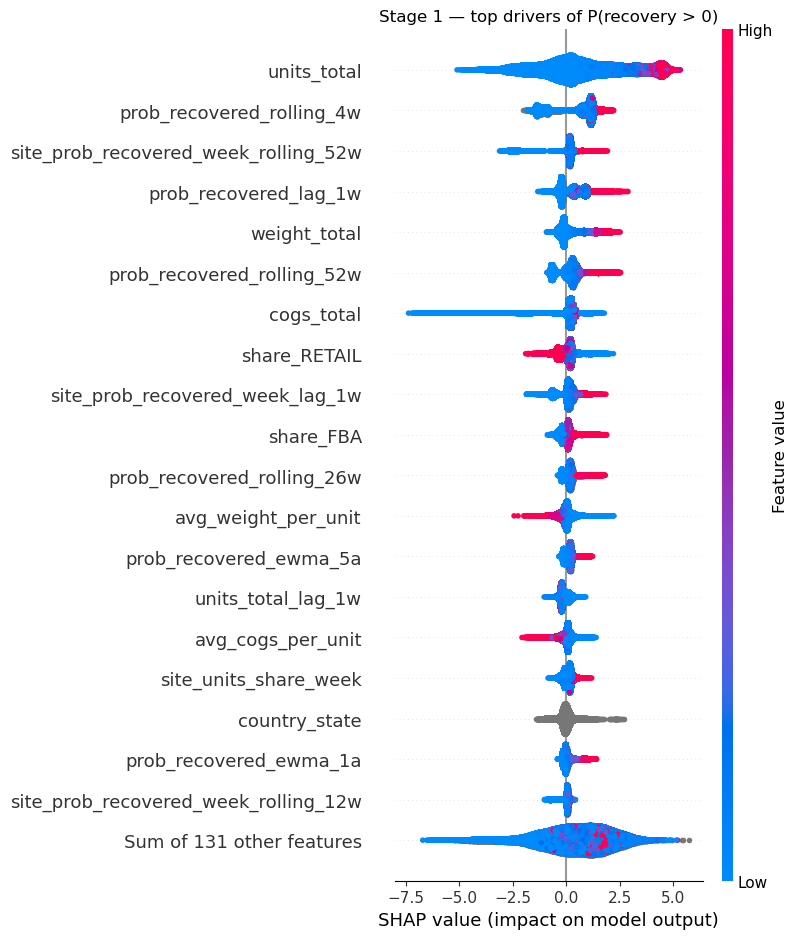

In [41]:
print("=== Stage 1: drivers of P(recovery > 0) ===")
explainer_clf = shap.TreeExplainer(model_clf)
sv_clf        = explainer_clf(X_shap_clf)
shap.plots.beeswarm(sv_clf, max_display=20, show=False)
plt.title("Stage 1 — top drivers of P(recovery > 0)")
plt.tight_layout(); plt.show()


=== Stage 2: drivers of E(rate | recovery > 0), logit space ===


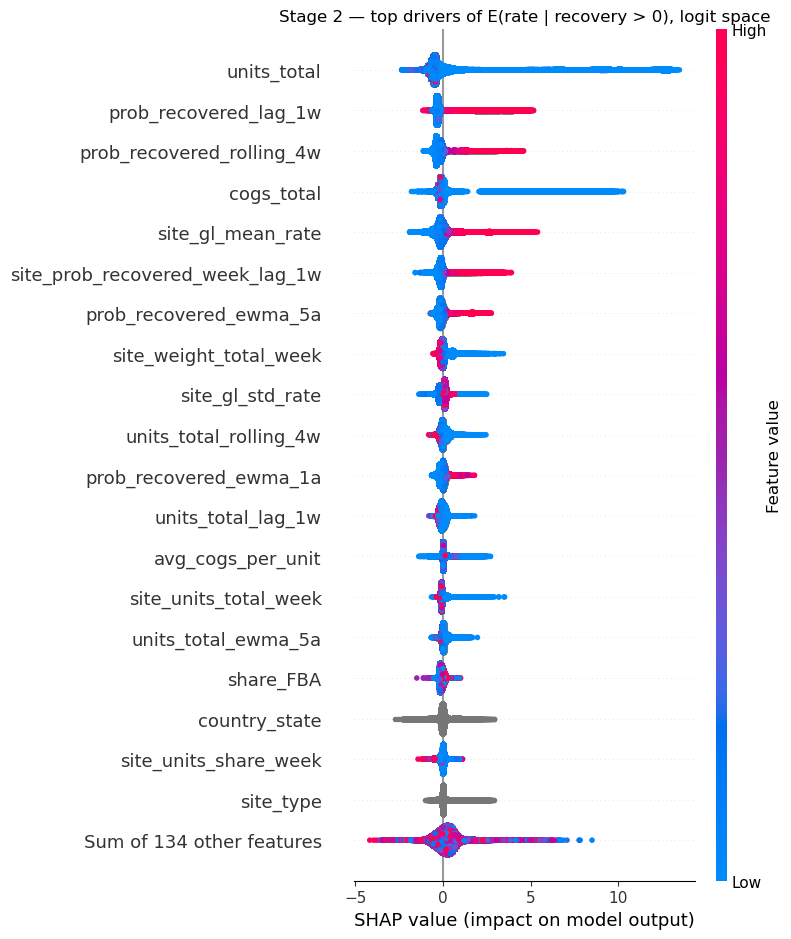

In [42]:
print("=== Stage 2: drivers of E(rate | recovery > 0), logit space ===")
explainer_reg = shap.TreeExplainer(model_reg)
sv_reg        = explainer_reg(X_shap_reg)
shap.plots.beeswarm(sv_reg, max_display=20, show=False)
plt.title("Stage 2 — top drivers of E(rate | recovery > 0), logit space")
plt.tight_layout(); plt.show()


## 3. Stage 2 baseline-vs-deviation decomposition

**Goal:** for each test row, separate Stage 2's prediction into
  - **baseline** — what the model would predict if only the long-run / structural signals were active (multi-week lags, rolling/EWMA, persisted site-GL means, calendar, identity categoricals, current-week site context),
  - **deviation** — the additional push-up (worse-than-baseline funnel entry) or pull-down (better-than-baseline) from the *current week's* GL volume/composition signals and any 1-week lag (the freshest evidence).

Operationally we sum SHAP contributions in each bucket per row, then sigmoid-transform to get probability-space contributions:
```
baseline_pred         = sigmoid(base_value + shap_baseline)
full_pred             = sigmoid(base_value + shap_baseline + shap_deviation)
deviation_contribution = full_pred - baseline_pred
```
Stage 1 is conceptually orthogonal (a recovery-happened-at-all gate), so the decomposition operates on Stage 2 only. The combined Approach A prediction is `p_nonzero * full_pred`.

We compute SHAP on the same stratified sample as the beeswarm above to keep compute bounded (TreeExplainer on ~7M rows would be too expensive for stakeholder-level summaries).

**Filter:** the decomposition is only meaningful when the model expects recovery to happen at all. We restrict it to rows where `p_nonzero > 0.5`, i.e. Stage 1 predicts the recovery funnel was triggered. On rows where Stage 1 is essentially zero, Stage 2's logit-space contributions get squeezed into a tiny probability window where decomposing baseline vs deviation is misleading.

In [43]:
deviation_features = list(
    dict.fromkeys(  # preserve order, drop duplicates
        gl_volume_cols
        + gl_composition_cols
        + [c for c in extended_features if c.endswith("_lag_1w")]
    )
)
deviation_features = [c for c in deviation_features if c in extended_features]
baseline_features  = [c for c in extended_features if c not in set(deviation_features)]

assert set(deviation_features).isdisjoint(baseline_features)
assert set(deviation_features) | set(baseline_features) == set(extended_features)
print(f"deviation features: {len(deviation_features):3d}    baseline features: {len(baseline_features):3d}")
print(f"deviation includes (sample): {deviation_features[:6]} ...")


deviation features:  24    baseline features: 129
deviation includes (sample): ['units_total', 'cogs_total', 'weight_total', 'avg_cogs_per_unit', 'avg_weight_per_unit', 'cogs_per_unit_weight'] ...


In [44]:
from scipy.special import expit

feat_index = {f: i for i, f in enumerate(extended_features)}
dev_idx    = np.array([feat_index[f] for f in deviation_features])
base_idx   = np.array([feat_index[f] for f in baseline_features])

# Restrict the decomposition to rows where Stage 1 expects recovery to happen.
decomp_mask  = p_nonzero[shap_idx] > 0.5
decomp_local = np.where(decomp_mask)[0]                # indices into the SHAP sample
decomp_idx   = shap_idx[decomp_mask]                   # indices into df_test / X_test_reg
print(f"SHAP sample: {len(shap_idx):,}    decomposition subset (p_nonzero > 0.5): {decomp_mask.sum():,}")

sv_reg_decomp = sv_reg[decomp_local]

shap_dev   = sv_reg_decomp.values[:, dev_idx ].sum(axis=1)
shap_base  = sv_reg_decomp.values[:, base_idx].sum(axis=1)
base_value = sv_reg_decomp.base_values

baseline_pred           = expit(base_value + shap_base)
full_pred               = expit(base_value + shap_base + shap_dev)
deviation_contribution  = full_pred - baseline_pred

# Sanity check: full_pred should match the model's actual e_rate on these rows.
e_rate_subset = e_rate[decomp_idx]
max_diff = np.abs(full_pred - e_rate_subset).max()
print(f"max |full_pred - e_rate| on decomposition subset: {max_diff:.2e}")
assert max_diff < 1e-3, "SHAP decomposition does not reconstruct the model output"

# Attach decomposition to the filtered diagnostics rows for plotting / tables.
decomp = (
    diagnostics[decomp_idx]
    .with_columns([
        pl.Series("baseline_pred",          baseline_pred),
        pl.Series("full_pred",              full_pred),
        pl.Series("deviation_contribution", deviation_contribution),
    ])
)
print("decomp shape:", decomp.shape)


SHAP sample: 644,511    decomposition subset (p_nonzero > 0.5): 435,216


max |full_pred - e_rate| on decomposition subset: 1.46e-06
decomp shape: (435216, 16)


### Distribution of deviation contributions

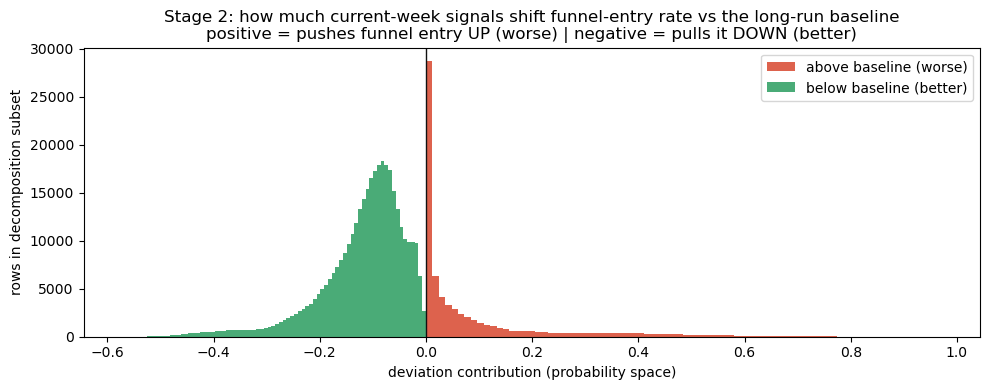

mean |deviation|        : 0.1149  (avg shift in pp)
mean signed deviation   : -0.0839  (>0 means current-week signals on average push funnel entry up)
5%-95% deviation range  : [-0.2611, +0.0798]


In [45]:
BAD_COLOR     = "#D7472E"   # red — pushed funnel-entry UP vs baseline (worse)
GOOD_COLOR    = "#2A9D5F"   # green — pulled funnel-entry DOWN vs baseline (better)
BASELINE_COLOR = "#B8C7D6"  # neutral — long-run baseline component
ZERO_LINE     = "#111"

fig, ax = plt.subplots(figsize=(10, 4))
pos_mask = deviation_contribution >= 0
ax.hist(deviation_contribution[pos_mask],  bins=80, color=BAD_COLOR,  alpha=0.85, label="above baseline (worse)")
ax.hist(deviation_contribution[~pos_mask], bins=80, color=GOOD_COLOR, alpha=0.85, label="below baseline (better)")
ax.axvline(0, color=ZERO_LINE, linewidth=1)
ax.set_xlabel("deviation contribution (probability space)")
ax.set_ylabel("rows in decomposition subset")
ax.set_title("Stage 2: how much current-week signals shift funnel-entry rate vs the long-run baseline\npositive = pushes funnel entry UP (worse) | negative = pulls it DOWN (better)")
ax.legend()
plt.tight_layout(); plt.show()

mean_abs = float(np.abs(deviation_contribution).mean())
mean_signed = float(deviation_contribution.mean())
q05, q95 = np.quantile(deviation_contribution, [0.05, 0.95])
print(f"mean |deviation|        : {mean_abs:.4f}  (avg shift in pp)")
print(f"mean signed deviation   : {mean_signed:+.4f}  (>0 means current-week signals on average push funnel entry up)")
print(f"5%-95% deviation range  : [{q05:+.4f}, {q95:+.4f}]")


### Mean baseline vs deviation by true-rate bucket

Stacked bars show, for each bucket of *actual* funnel-entry rate, how much of the Stage 2 prediction comes from the long-run baseline vs the current-week deviation. If high-funnel-entry weeks are explained mainly by deviation, the model is leaning on situational signals; if mainly by baseline, it is recognising structurally high-loss site-GL combos.

shape: (5, 6)
┌─────────────┬────────┬───────────────┬────────────────┬───────────┬─────────────┐
│ rate_bucket ┆ n      ┆ mean_baseline ┆ mean_deviation ┆ mean_full ┆ mean_actual │
│ ---         ┆ ---    ┆ ---           ┆ ---            ┆ ---       ┆ ---         │
│ enum        ┆ u32    ┆ f32           ┆ f32            ┆ f32       ┆ f64         │
╞═════════════╪════════╪═══════════════╪════════════════╪═══════════╪═════════════╡
│ zero        ┆ 10402  ┆ 0.203469      ┆ -0.043204      ┆ 0.160265  ┆ 0.0         │
│ 0-10%       ┆ 170127 ┆ 0.153832      ┆ -0.099249      ┆ 0.054583  ┆ 0.040201    │
│ 10-30%      ┆ 150953 ┆ 0.331326      ┆ -0.141882      ┆ 0.189445  ┆ 0.166158    │
│ 30-60%      ┆ 46584  ┆ 0.426956      ┆ -0.026262      ┆ 0.400694  ┆ 0.418117    │
│ >60%        ┆ 57150  ┆ 0.835758      ┆ 0.060304       ┆ 0.896062  ┆ 0.944245    │
└─────────────┴────────┴───────────────┴────────────────┴───────────┴─────────────┘


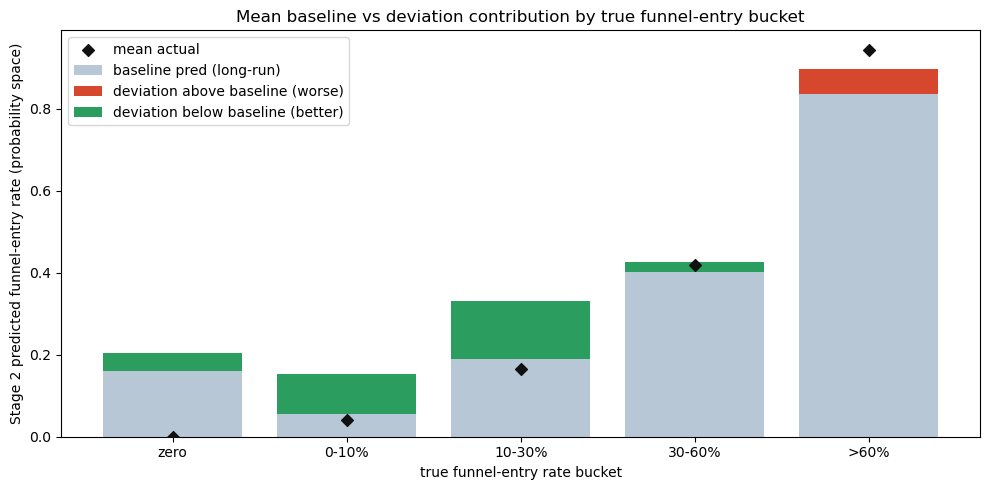

In [46]:
agg = (
    decomp
    .group_by("rate_bucket")
    .agg([
        pl.len().alias("n"),
        pl.col("baseline_pred").mean().alias("mean_baseline"),
        pl.col("deviation_contribution").mean().alias("mean_deviation"),
        pl.col("full_pred").mean().alias("mean_full"),
        pl.col("y_true").mean().alias("mean_actual"),
    ])
    .with_columns(pl.col("rate_bucket").cast(pl.Enum(BUCKET_ORDER)))
    .sort("rate_bucket")
)
print(agg)

fig, ax = plt.subplots(figsize=(10, 5))
buckets = agg["rate_bucket"].cast(pl.Utf8).to_list()
baseline_vals  = agg["mean_baseline"].to_numpy()
deviation_vals = agg["mean_deviation"].to_numpy()
actual_vals    = agg["mean_actual"].to_numpy()

pos_dev = np.clip(deviation_vals, 0, None)
neg_dev = np.clip(deviation_vals, None, 0)

ax.bar(buckets, baseline_vals, color=BASELINE_COLOR, label="baseline pred (long-run)")
ax.bar(buckets, pos_dev,       bottom=baseline_vals, color=BAD_COLOR,  label="deviation above baseline (worse)")
ax.bar(buckets, neg_dev,       bottom=baseline_vals, color=GOOD_COLOR, label="deviation below baseline (better)")
ax.scatter(buckets, actual_vals, color=ZERO_LINE, marker="D", zorder=5, label="mean actual")
ax.set_xlabel("true funnel-entry rate bucket")
ax.set_ylabel("Stage 2 predicted funnel-entry rate (probability space)")
ax.set_title("Mean baseline vs deviation contribution by true funnel-entry bucket")
ax.legend()
plt.tight_layout(); plt.show()


### Where do current-week signals matter most?

Each dot is a test-set row. The y=x reference line is what the prediction would be if the deviation contribution were zero. Rows **above** the line (red) are weeks where current-week conditions push funnel entry *up* relative to the long-run baseline (worse outcome); rows **below** the line (green) are weeks where they pull it *down* (better outcome).

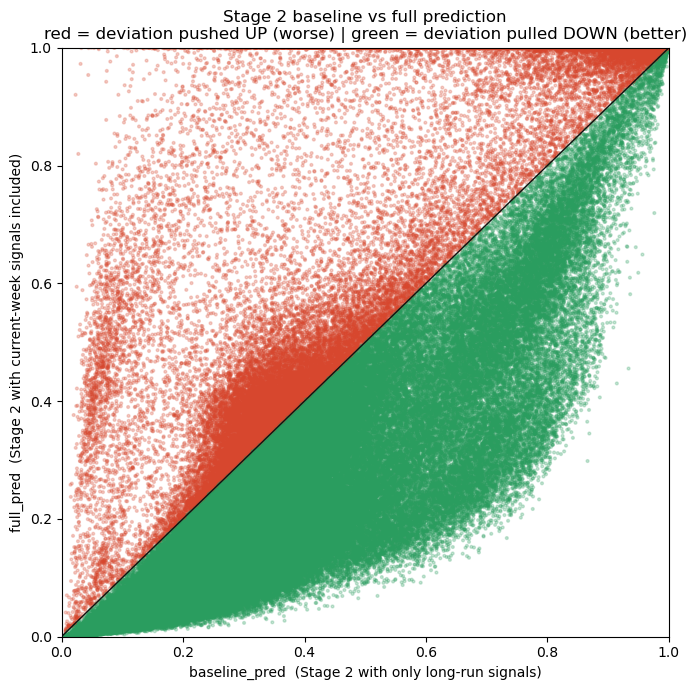

In [47]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = np.where(deviation_contribution >= 0, BAD_COLOR, GOOD_COLOR)
ax.scatter(baseline_pred, full_pred, c=colors, s=4, alpha=0.25)
ax.plot([0, 1], [0, 1], color=ZERO_LINE, linewidth=1)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("baseline_pred  (Stage 2 with only long-run signals)")
ax.set_ylabel("full_pred  (Stage 2 with current-week signals included)")
ax.set_title("Stage 2 baseline vs full prediction\nred = deviation pushed UP (worse) | green = deviation pulled DOWN (better)")
plt.tight_layout(); plt.show()


### Top 10 “worse than baseline” and “better than baseline” weeks

Concrete examples for stakeholder narratives. **Worse-than-baseline** = current-week signals pushed predicted funnel entry above what the long-run pattern would suggest (business pain). **Better-than-baseline** = current-week signals pulled it below.

In [48]:
show_cols = [
    "hashed_fc", "gl_product_group", "year", "month", "week",
    "units_total", "y_true", "p_nonzero",
    "baseline_pred", "full_pred", "deviation_contribution",
    "pred_prob", "abs_err",
]

worse_than_baseline = (
    decomp.sort("deviation_contribution", descending=True)
    .head(10)
    .select(show_cols)
)
better_than_baseline = (
    decomp.sort("deviation_contribution", descending=False)
    .head(10)
    .select(show_cols)
)
print("Top 10 — deviation pushed funnel-entry rate UP the most (worse than baseline):")
print(worse_than_baseline)
print()
print("Top 10 — deviation pulled funnel-entry rate DOWN the most (better than baseline):")
print(better_than_baseline)


Top 10 — deviation pushed funnel-entry rate UP the most (worse than baseline):
shape: (10, 13)
┌─────┬─────┬─────┬───────┬──────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ has ┆ gl_ ┆ yea ┆ month ┆ week ┆ units_ ┆ y_true ┆ p_non ┆ basel ┆ full_ ┆ devia ┆ pred_ ┆ abs_e │
│ hed ┆ pro ┆ r   ┆ ---   ┆ ---  ┆ total  ┆ ---    ┆ zero  ┆ ine_p ┆ pred  ┆ tion_ ┆ prob  ┆ rr    │
│ _fc ┆ duc ┆ --- ┆ i64   ┆ f64  ┆ ---    ┆ f64    ┆ ---   ┆ red   ┆ ---   ┆ contr ┆ ---   ┆ ---   │
│ --- ┆ t_g ┆ i64 ┆       ┆      ┆ f64    ┆        ┆ f32   ┆ ---   ┆ f32   ┆ ibuti ┆ f32   ┆ f64   │
│ str ┆ rou ┆     ┆       ┆      ┆        ┆        ┆       ┆ f32   ┆       ┆ on    ┆       ┆       │
│     ┆ p   ┆     ┆       ┆      ┆        ┆        ┆       ┆       ┆       ┆ ---   ┆       ┆       │
│     ┆ --- ┆     ┆       ┆      ┆        ┆        ┆       ┆       ┆       ┆ f32   ┆       ┆       │
│     ┆ f64 ┆     ┆       ┆      ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆     

### Walkthrough: one stakeholder example

Pick the test row with the largest |deviation_contribution| and produce a stakeholder-friendly narrative: historical baseline rate, this week's adjustment, predicted rate, and the top current-week drivers with plain-language descriptions comparing the current value to its long-run reference. The Stage 2 SHAP waterfall below the narrative shows the underlying logit-space contributions for verification.

In [49]:
FEATURE_LABEL = {
    "share_hazmat": "Hazmat share",
    "share_food": "Food share",
    "share_non_food": "Non-food share",
    "share_pet_food": "Pet-food share",
    "share_RETAIL": "Retail share",
    "share_FBA": "FBA share",
    "units_total": "Total units",
    "cogs_total": "Total COGS",
    "weight_total": "Total weight",
    "avg_cogs_per_unit": "Avg COGS per unit",
    "avg_weight_per_unit": "Avg weight per unit",
    "cogs_per_unit_weight": "COGS per unit weight",
    "prob_recovered": "Funnel-entry rate",
}

def humanize(feat: str) -> str:
    base, suffix_label = feat, ""
    if feat.endswith("_lag_1w"):
        base = feat[:-len("_lag_1w")]
        suffix_label = " (last week)"
    label = FEATURE_LABEL.get(base, base)
    return label + suffix_label

def fmt_value(feat: str, val) -> str:
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return "n/a"
    if feat.startswith("share_") or "prob_recovered" in feat:
        return f"{val*100:.1f}%"
    if any(k in feat for k in (
        "units_total", "cogs_total", "weight_total",
        "site_units_total_week", "site_weight_total_week",
    )):
        return f"{val:,.0f}"
    return f"{val:.3f}"

def find_reference(feat: str, available: set[str]) -> str | None:
    """Find a long-run baseline column to compare the current value against."""
    if feat.endswith("_lag_1w"):
        stem = feat[:-len("_lag_1w")]
        candidates = [
            f"{stem}_rolling_4w", f"{stem}_rolling_12w",
            f"{stem}_lag_4w",     f"{stem}_lag_12w",
        ]
    else:
        candidates = [
            f"{feat}_rolling_52w", f"{feat}_rolling_12w",
            f"{feat}_rolling_4w",  f"{feat}_lag_52w", f"{feat}_lag_4w",
        ]
    for c in candidates:
        if c in available:
            return c
    return None

def reference_label(ref_col: str) -> str:
    if "_rolling_52w" in ref_col: return "52-week average"
    if "_rolling_26w" in ref_col: return "26-week average"
    if "_rolling_12w" in ref_col: return "12-week average"
    if "_rolling_4w"  in ref_col: return "4-week average"
    if "_lag_52w" in ref_col:     return "same week last year"
    if "_lag_12w" in ref_col:     return "12 weeks ago"
    if "_lag_4w"  in ref_col:     return "4 weeks ago"
    return ref_col


In [56]:
available_cols = set(extended_features)

def print_decomposition_example(ex_local: int, top_k: int = 6, show_waterfall: bool = True) -> None:
    """Print a stakeholder-friendly narrative for one row in the decomposition subset.

    `ex_local` is an index into `decomp` / `sv_reg_decomp` (the p_nonzero>0.5 subset),
    not into df_test directly.
    """
    ex_global = int(decomp_idx[ex_local])
    row       = decomp.row(ex_local, named=True)
    X_row     = X_test_reg.iloc[ex_global]

    # Per-feature SHAP in logit space, proportionally allocated to probability space
    # so the parts sum exactly to deviation_contribution.
    row_shap_dev_logit = sv_reg_decomp.values[ex_local, dev_idx]
    logit_total        = row_shap_dev_logit.sum()
    row_dev_total      = float(row['deviation_contribution'])
    prob_scale         = row_dev_total / logit_total if abs(logit_total) > 1e-9 else 0.0
    row_shap_dev_prob  = row_shap_dev_logit * prob_scale

    order = np.argsort(-np.abs(row_shap_dev_prob))[:top_k]
    lines = []
    for j in order:
        feat    = deviation_features[j]
        cur_val = X_row[feat] if feat in X_row.index else None
        ref_col = find_reference(feat, available_cols)
        ref_val = X_row[ref_col] if ref_col is not None else None
        contrib = row_shap_dev_prob[j]
        arrow   = '↑' if contrib >= 0 else '↓'
        label   = humanize(feat)
        if ref_col is None:
            detail = f"current = {fmt_value(feat, cur_val)}"
        else:
            detail = (f"{fmt_value(feat, cur_val)} vs {fmt_value(ref_col, ref_val)} "
                      f"({reference_label(ref_col)})")
        lines.append((arrow, label, contrib, detail))

    header_dir = ("above baseline (worse than usual)" if row_dev_total >= 0
                  else "below baseline (better than usual)")

    print("=" * 78)
    print(f"Site: {row['hashed_fc'][:14]}…   |   GL: {row['gl_product_group']}   |   "
          f"Week: {row['week']}  ({row['year']}-M{row['month']})")
    print("=" * 78)
    print()
    print(f"Historical baseline rate:    {row['baseline_pred']:.2f}")
    print(f"This week's adjustment:     {row_dev_total:+.2f}   ({header_dir})")
    print(f"Predicted funnel-entry rate: {row['full_pred']:.2f}")
    print(f"  P(recovery>0): {row['p_nonzero']:.2f}")
    print(f"  combined:    {row['pred_prob']:.2f}   (Stage 1 × Stage 2)")
    print(f"Actual funnel-entry rate:    {row['y_true']:.2f}")
    print()
    title = ("Why ABOVE baseline this week:" if row_dev_total >= 0
             else "Why BELOW baseline this week:")
    print(title)
    for arrow, label, contrib, detail in lines:
        print(f"  {arrow} {label:<28s} ({contrib:+.2f})    {detail}")
    print()

    if show_waterfall:
        print("-" * 78)
        print("Stage 2 SHAP waterfall (logit space) — full feature view:")
        shap.plots.waterfall(sv_reg_decomp[ex_local], max_display=15)


Site: 6948b502c64057…   |   GL: 75.0   |   Week: 29.0  (2025-M7)

Historical baseline rate:    0.03
This week's adjustment:     +0.97   (above baseline (worse than usual))
Predicted funnel-entry rate: 1.00
  P(recovery>0): 0.99
  combined:    0.99   (Stage 1 × Stage 2)
Actual funnel-entry rate:    1.00

Why ABOVE baseline this week:
  ↑ Total COGS                   (+0.37)    2 vs 103,630 (52-week average)
  ↑ Total units                  (+0.33)    8 vs 2,524 (52-week average)
  ↑ Funnel-entry rate (last week) (+0.25)    100.0% vs 33.2% (4-week average)
  ↑ site_prob_recovered_week (last week) (+0.10)    99.4% vs 31.7% (4-week average)
  ↓ Total units (last week)      (-0.02)    88 vs 417 (4-week average)
  ↓ Retail share                 (-0.02)    0.0% vs 79.9% (52-week average)

------------------------------------------------------------------------------
Stage 2 SHAP waterfall (logit space) — full feature view:


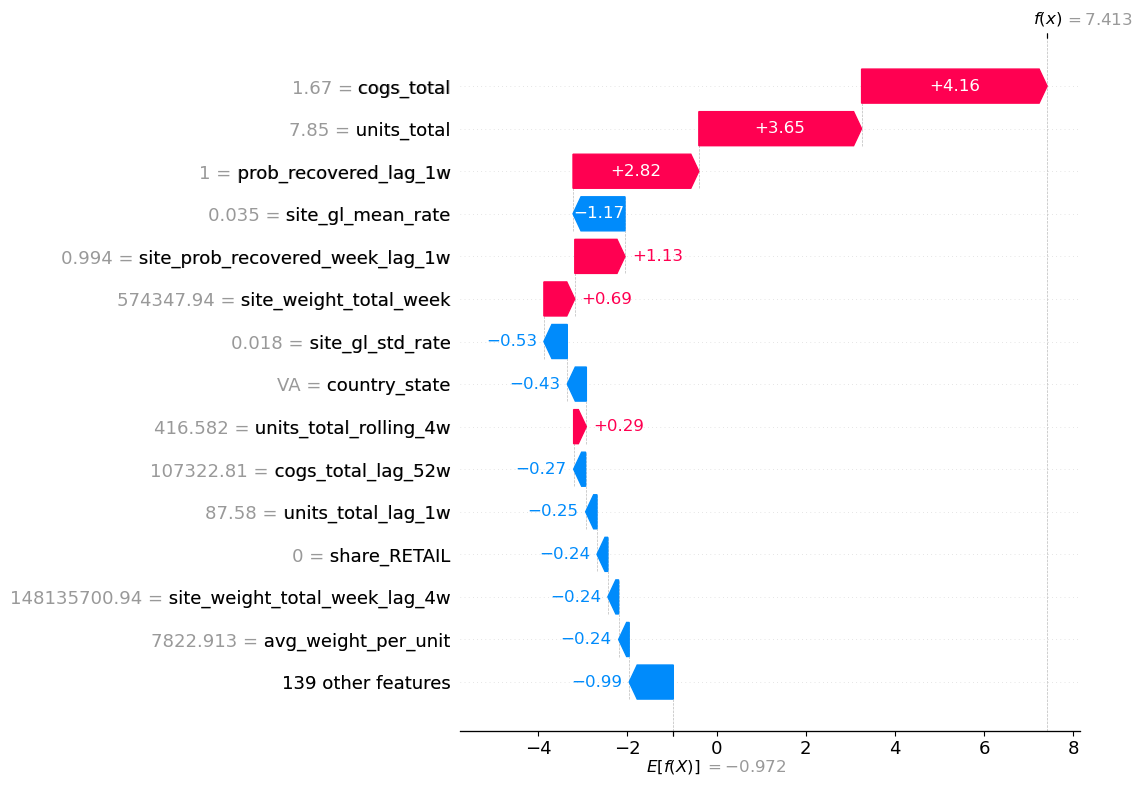


Site: bb0856bc0c5c5e…   |   GL: 421.0   |   Week: 1.0  (2025-M12)

Historical baseline rate:    0.04
This week's adjustment:     +0.95   (above baseline (worse than usual))
Predicted funnel-entry rate: 1.00
  P(recovery>0): 0.70
  combined:    0.70   (Stage 1 × Stage 2)
Actual funnel-entry rate:    1.00

Why ABOVE baseline this week:
  ↑ Total COGS                   (+0.68)    2 vs n/a (52-week average)
  ↑ Funnel-entry rate (last week) (+0.21)    n/a vs n/a (4-week average)
  ↑ Avg COGS per unit            (+0.08)    current = 0.015
  ↓ Total units                  (-0.06)    112 vs n/a (52-week average)
  ↑ site_prob_recovered_week (last week) (+0.05)    n/a vs n/a (4-week average)
  ↑ FBA share                    (+0.02)    100.0% vs n/a (52-week average)

------------------------------------------------------------------------------
Stage 2 SHAP waterfall (logit space) — full feature view:


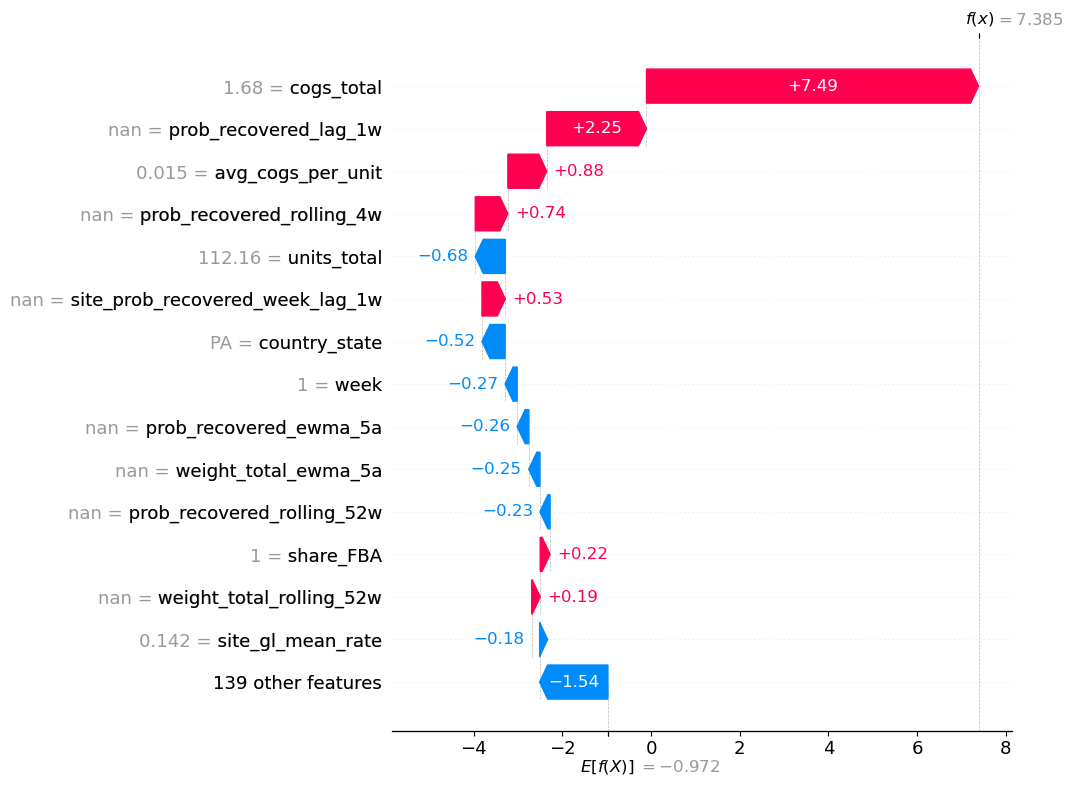


Site: 9b0a013ce165bd…   |   GL: 751.0   |   Week: 42.0  (2025-M10)

Historical baseline rate:    0.05
This week's adjustment:     +0.95   (above baseline (worse than usual))
Predicted funnel-entry rate: 1.00
  P(recovery>0): 0.52
  combined:    0.52   (Stage 1 × Stage 2)
Actual funnel-entry rate:    1.00

Why ABOVE baseline this week:
  ↑ Total COGS                   (+0.43)    2 vs 18 (52-week average)
  ↑ Total units                  (+0.26)    7 vs 20 (52-week average)
  ↑ Funnel-entry rate (last week) (+0.17)    n/a vs 77.1% (4-week average)
  ↑ Avg COGS per unit            (+0.06)    current = 0.237
  ↑ site_prob_recovered_week (last week) (+0.03)    n/a vs 2.6% (4-week average)
  ↑ Total weight                 (+0.01)    1,150 vs 7,291 (52-week average)

------------------------------------------------------------------------------
Stage 2 SHAP waterfall (logit space) — full feature view:


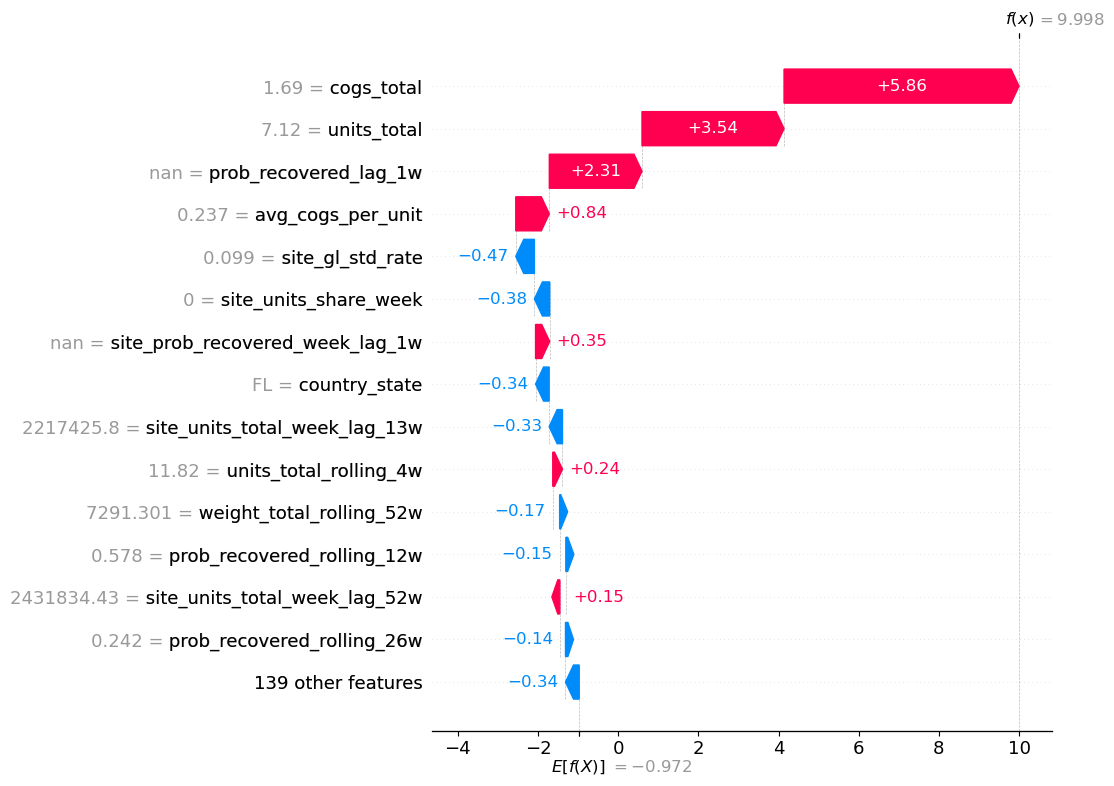


Site: 200bd0b9fbda63…   |   GL: 201.0   |   Week: 26.0  (2025-M6)

Historical baseline rate:    0.87
This week's adjustment:     -0.57   (below baseline (better than usual))
Predicted funnel-entry rate: 0.30
  P(recovery>0): 1.00
  combined:    0.30   (Stage 1 × Stage 2)
Actual funnel-entry rate:    0.11

Why BELOW baseline this week:
  ↓ Total units                  (-0.16)    2,810 vs 813 (52-week average)
  ↓ Total COGS                   (-0.08)    508,507 vs 60,655 (52-week average)
  ↓ Avg weight per unit          (-0.07)    current = 30820.506
  ↓ Total weight                 (-0.07)    86,598,842 vs 17,905,603 (52-week average)
  ↓ Funnel-entry rate (last week) (-0.06)    10.6% vs 16.3% (4-week average)
  ↓ FBA share                    (-0.05)    31.9% vs 51.6% (52-week average)

------------------------------------------------------------------------------
Stage 2 SHAP waterfall (logit space) — full feature view:


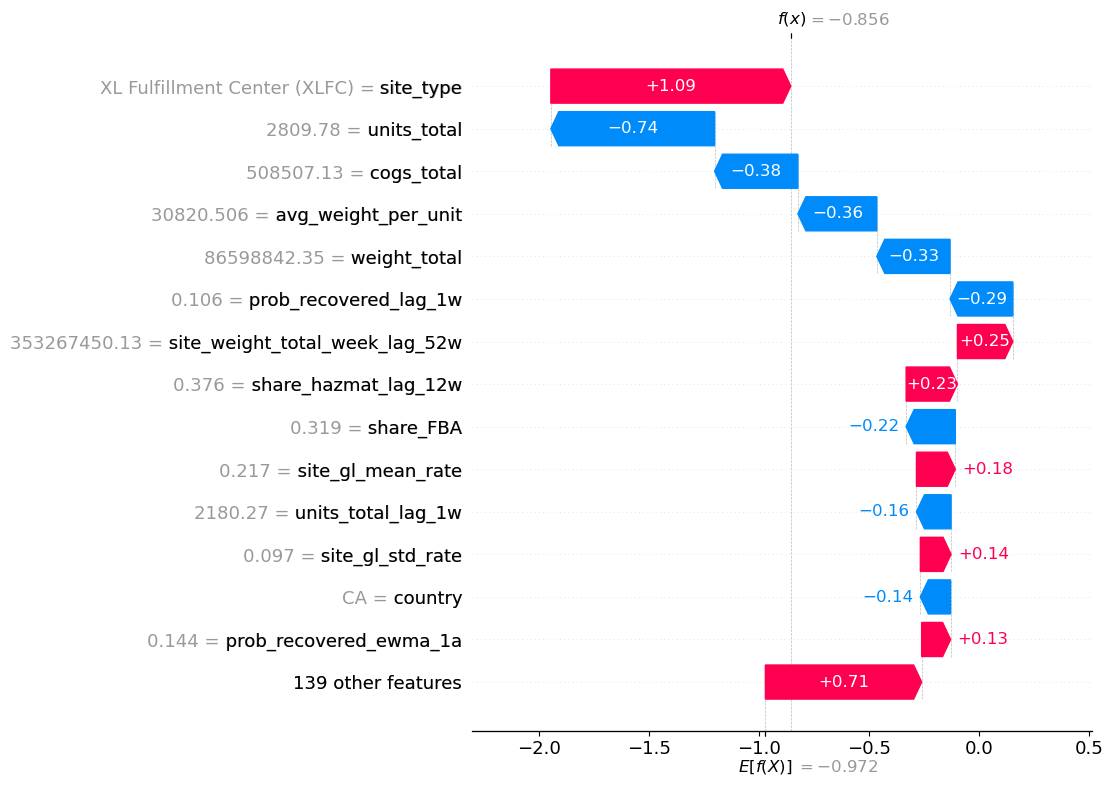


Site: 0572c7f1e7ed6a…   |   GL: 504.0   |   Week: 28.0  (2025-M7)

Historical baseline rate:    0.73
This week's adjustment:     -0.57   (below baseline (better than usual))
Predicted funnel-entry rate: 0.17
  P(recovery>0): 1.00
  combined:    0.17   (Stage 1 × Stage 2)
Actual funnel-entry rate:    0.04

Why BELOW baseline this week:
  ↓ Total units                  (-0.11)    3,313 vs 939 (52-week average)
  ↓ Avg weight per unit          (-0.09)    current = 27063.811
  ↓ Total COGS                   (-0.09)    1,880,423 vs 402,521 (52-week average)
  ↓ Total weight                 (-0.09)    89,669,714 vs 21,601,942 (52-week average)
  ↓ Funnel-entry rate (last week) (-0.06)    20.5% vs 16.0% (4-week average)
  ↓ FBA share                    (-0.05)    6.4% vs 8.5% (52-week average)

------------------------------------------------------------------------------
Stage 2 SHAP waterfall (logit space) — full feature view:


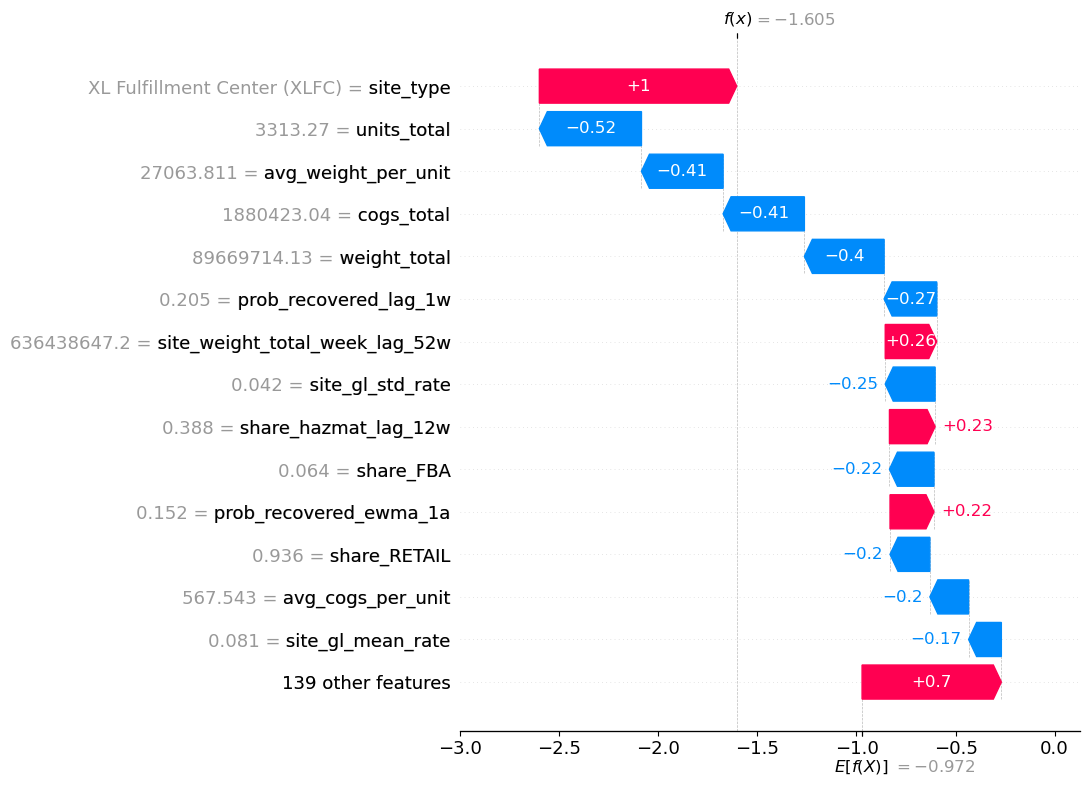


Site: 200bd0b9fbda63…   |   GL: 504.0   |   Week: 41.0  (2025-M10)

Historical baseline rate:    0.78
This week's adjustment:     -0.56   (below baseline (better than usual))
Predicted funnel-entry rate: 0.22
  P(recovery>0): 1.00
  combined:    0.22   (Stage 1 × Stage 2)
Actual funnel-entry rate:    0.05

Why BELOW baseline this week:
  ↓ Total units                  (-0.12)    1,579 vs 713 (52-week average)
  ↓ Total COGS                   (-0.09)    822,375 vs 278,227 (52-week average)
  ↓ Avg weight per unit          (-0.09)    current = 25652.593
  ↓ Total weight                 (-0.08)    40,509,036 vs 16,013,074 (52-week average)
  ↓ Funnel-entry rate (last week) (-0.06)    8.7% vs 15.9% (4-week average)
  ↓ FBA share                    (-0.05)    4.7% vs 8.3% (52-week average)

------------------------------------------------------------------------------
Stage 2 SHAP waterfall (logit space) — full feature view:


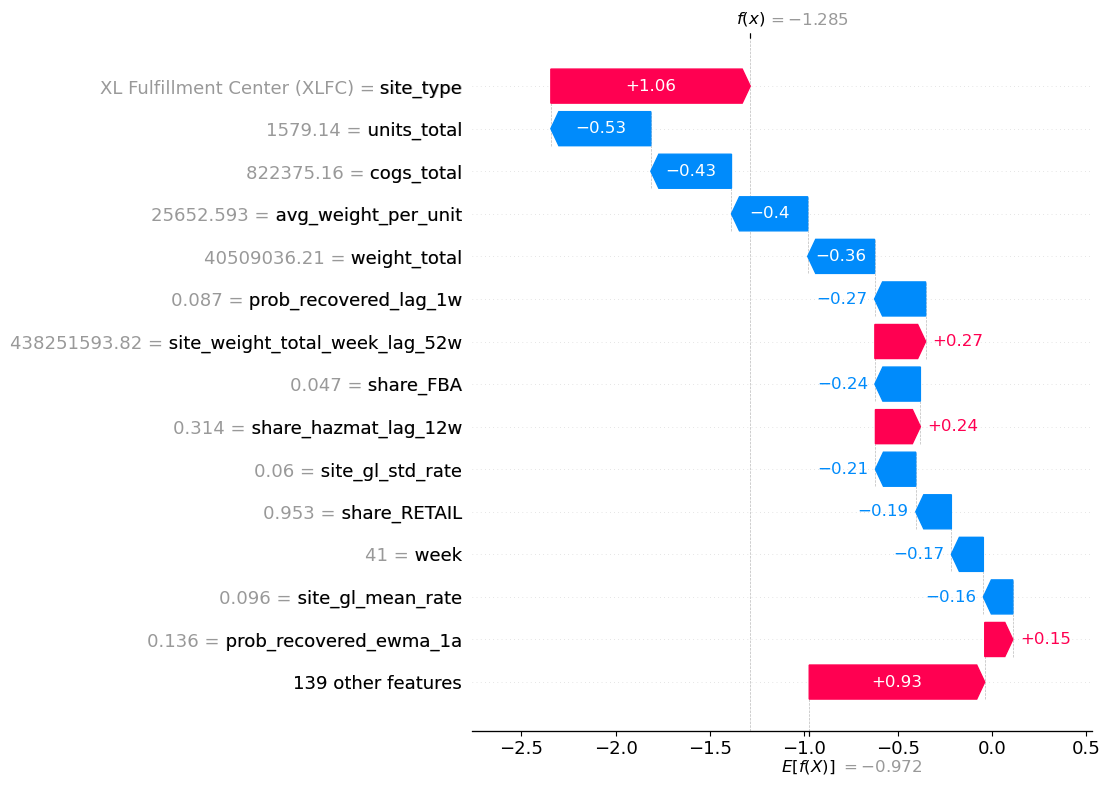

In [57]:
# Top-3 worst-than-baseline (deviation pushed funnel entry UP the most)
worst_local = np.argsort(-deviation_contribution)[:3]
for ex_local in worst_local:
    print_decomposition_example(int(ex_local), top_k=6, show_waterfall=True)
    print()

# Top-3 better-than-baseline (deviation pulled funnel entry DOWN the most)
best_local = np.argsort(deviation_contribution)[:3]
for ex_local in best_local:
    print_decomposition_example(int(ex_local), top_k=6, show_waterfall=True)
    print()

## 4. Top funnel-entry sites and GLs — monthly actual vs predicted

Volume-weighted ranking so high-throughput sites/GLs dominate (small sites with freak high-funnel-entry weeks don't crowd the panel). These are the **worst** performers from a business perspective — the sites/GLs with the largest predicted share of inventory falling into the recovery funnel.

In [53]:
MIN_UNITS = 5_000
TOP_N     = 20

site_rank = (
    diagnostics
    .group_by("hashed_fc")
    .agg([
        pl.col("units_total").sum().alias("units"),
        ((pl.col("pred_prob") * pl.col("units_total")).sum()
         / pl.col("units_total").sum()).alias("vw_pred"),
    ])
    .filter(pl.col("units") >= MIN_UNITS)
    .sort("vw_pred", descending=True)
    .head(TOP_N)
)
top_sites = site_rank['hashed_fc'].to_list()
print(f"top {len(top_sites)} sites (volume-weighted predicted funnel-entry rate — worst performers):")
print(site_rank)


top 20 sites (volume-weighted predicted funnel-entry rate — worst performers):
shape: (20, 3)
┌─────────────────────────────────┬───────────┬──────────┐
│ hashed_fc                       ┆ units     ┆ vw_pred  │
│ ---                             ┆ ---       ┆ ---      │
│ str                             ┆ f64       ┆ f64      │
╞═════════════════════════════════╪═══════════╪══════════╡
│ 176eb7a6ce3893837045bf1818e3b4… ┆ 2.3669e6  ┆ 0.999993 │
│ 5383500c9bc50d40908854036b68dc… ┆ 1582107.9 ┆ 0.999929 │
│ 8a5b55b0880b8b707cc76279e8dd72… ┆ 1.3121e6  ┆ 0.999863 │
│ 58a9db7f90c6afa41b8c838a285867… ┆ 411594.61 ┆ 0.999862 │
│ 0577a394e8079bcc0710c23791c582… ┆ 6.0309e6  ┆ 0.999842 │
│ 1ad318e79218f353296b14583d8c08… ┆ 4.0589e6  ┆ 0.998575 │
│ 7cd07df8f3343a17943949f89f4783… ┆ 442901.59 ┆ 0.991019 │
│ 6e9de8d2f6fcd7218a2822f38ccf49… ┆ 198657.54 ┆ 0.982054 │
│ e17cdadee58349ab86224f728d451e… ┆ 292579.74 ┆ 0.969879 │
│ 8f8d138652d2f11db73d2550242e56… ┆ 694903.75 ┆ 0.932143 │
│ e2e64e4905d5a56c45f

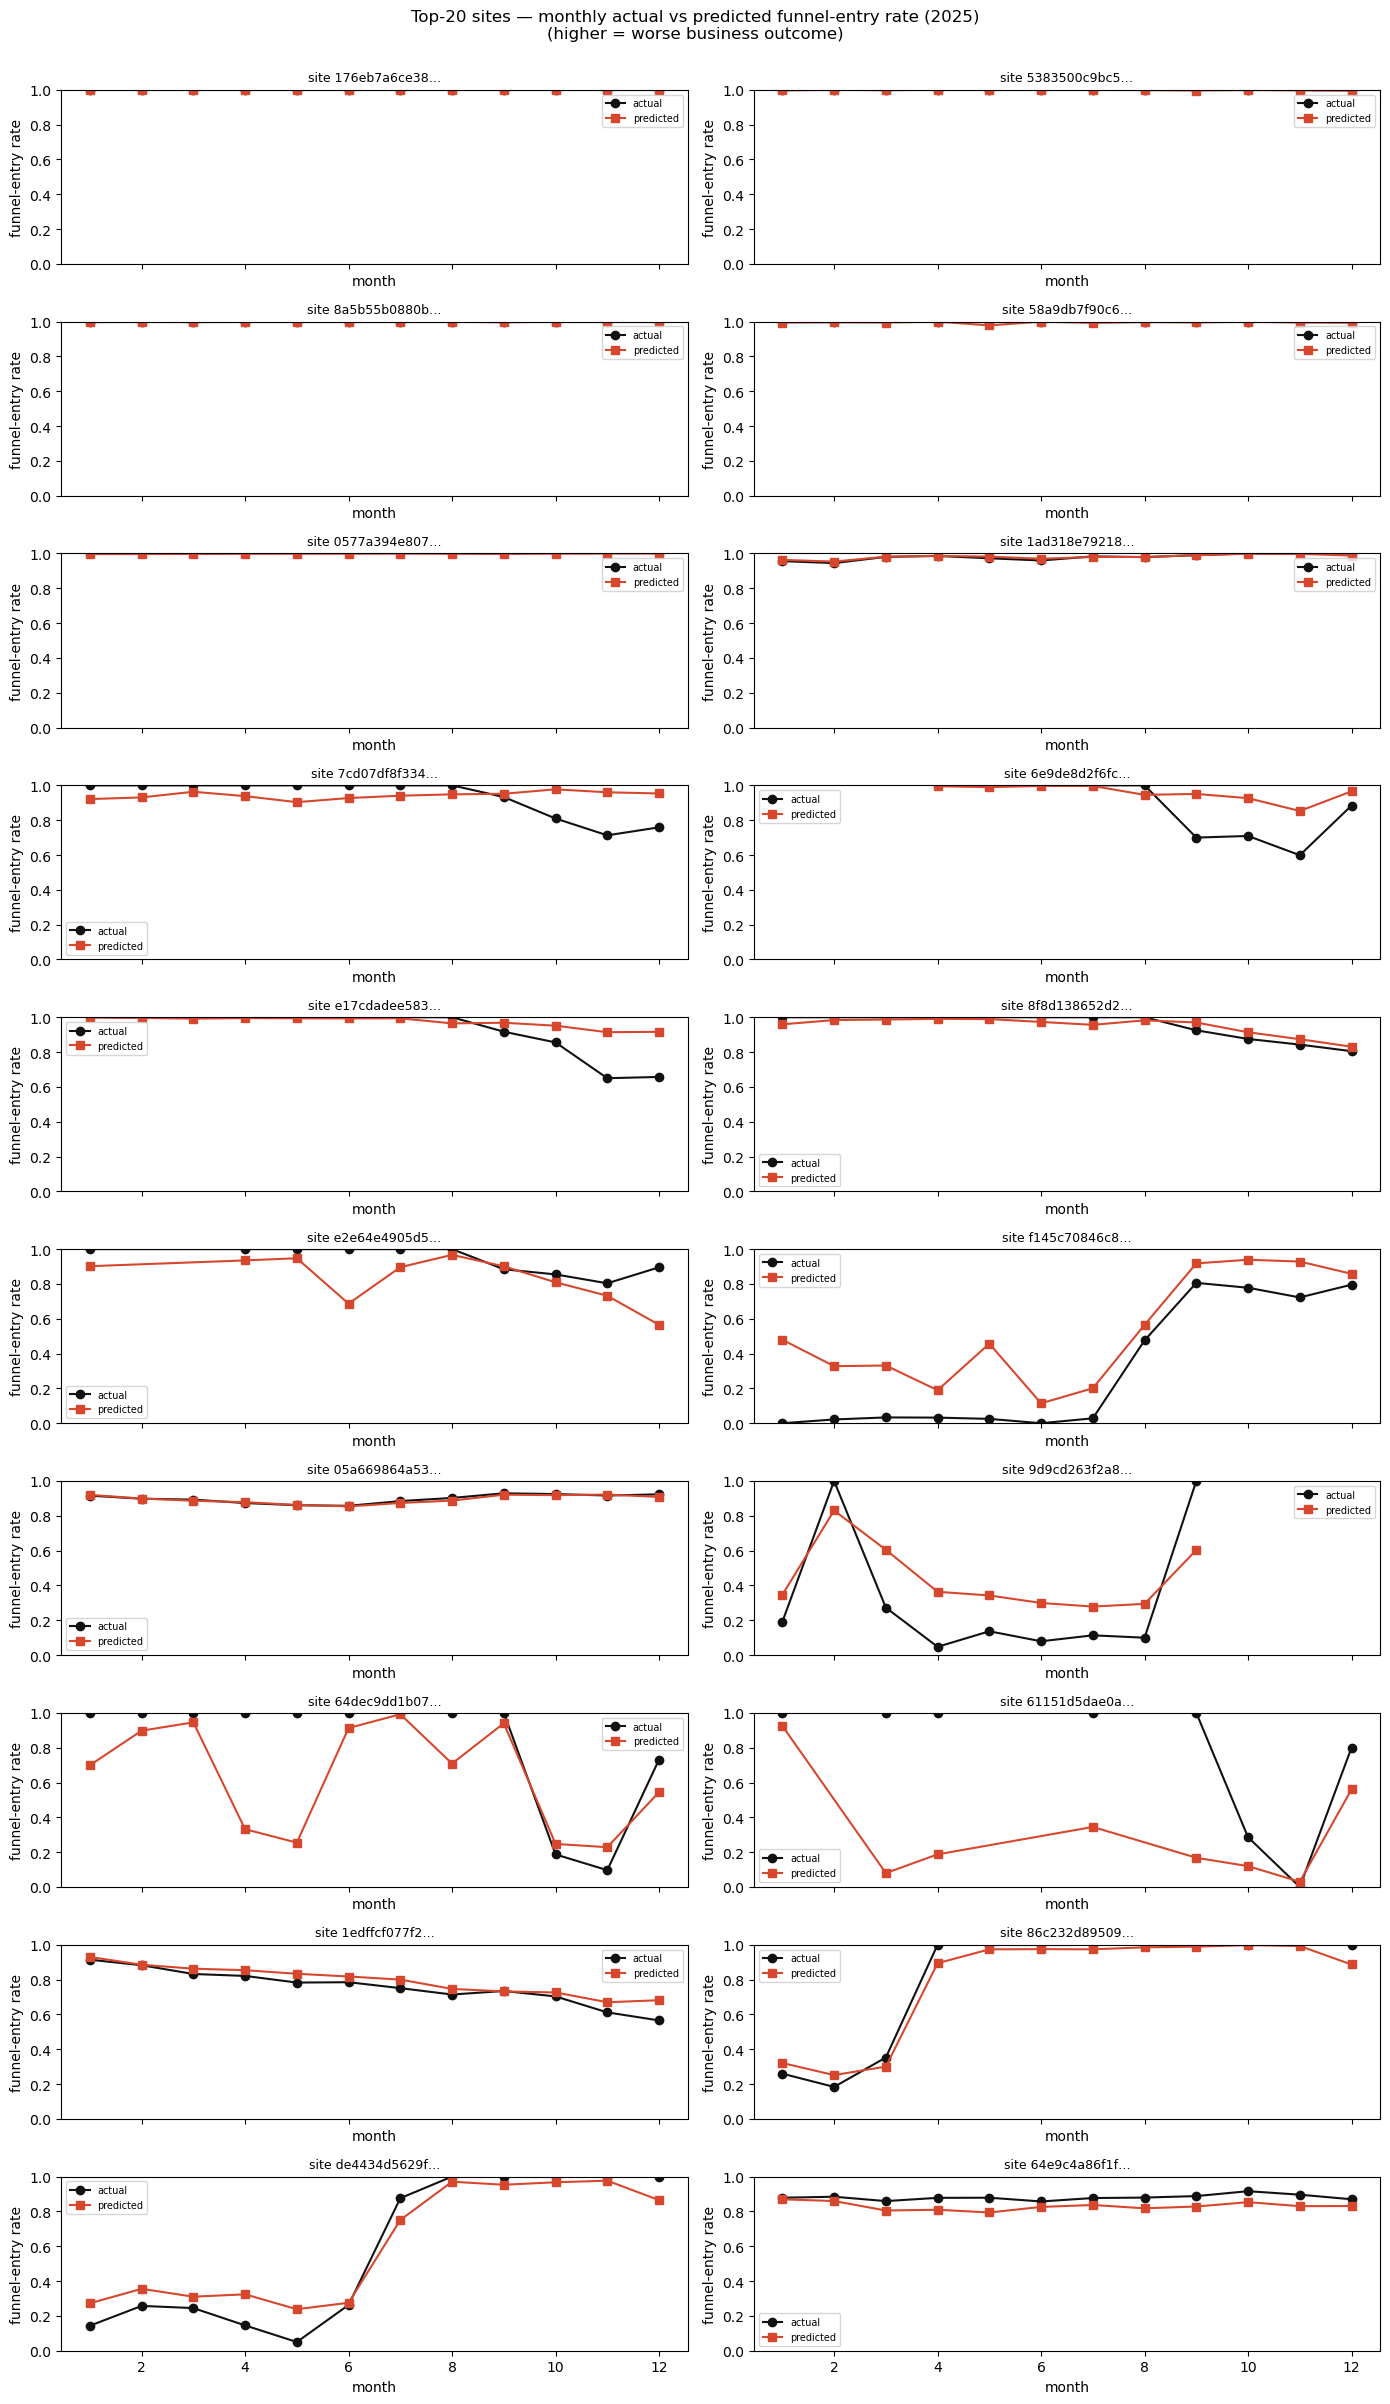

In [54]:
site_monthly = (
    diagnostics
    .filter(pl.col("hashed_fc").is_in(top_sites))
    .group_by(["hashed_fc", "month"])
    .agg([
        pl.col("y_true").mean().alias("mean_actual"),
        pl.col("pred_prob").mean().alias("mean_pred"),
        pl.len().alias("n"),
    ])
    .sort(["hashed_fc", "month"])
)

n_cols = 2
n_rows = (len(top_sites) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.4 * n_rows), sharex=True)
axes = axes.flatten()
for ax, site in zip(axes, top_sites):
    sub = site_monthly.filter(pl.col("hashed_fc") == site)
    ax.plot(sub["month"], sub["mean_actual"], color="#111",    marker="o", label="actual")
    ax.plot(sub["month"], sub["mean_pred"],   color="#D7472E", marker="s", label="predicted")
    ax.set_title(f"site {site[:12]}…", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlabel("month"); ax.set_ylabel("funnel-entry rate")
    ax.legend(fontsize=7)
for ax in axes[len(top_sites):]:
    ax.set_visible(False)
plt.suptitle(f"Top-{TOP_N} sites — monthly actual vs predicted funnel-entry rate (2025)\n(higher = worse business outcome)", y=1.00)
plt.tight_layout(); plt.show()


top 20 GLs (volume-weighted predicted funnel-entry rate — worst performers):
shape: (20, 3)
┌──────────────────┬───────────┬──────────┐
│ gl_product_group ┆ units     ┆ vw_pred  │
│ ---              ┆ ---       ┆ ---      │
│ f64              ┆ f64       ┆ f64      │
╞══════════════════╪═══════════╪══════════╡
│ 405.0            ┆ 6161.5    ┆ 0.808097 │
│ 366.0            ┆ 12335.95  ┆ 0.768017 │
│ 773.0            ┆ 9994.51   ┆ 0.673601 │
│ 27.0             ┆ 57819.79  ┆ 0.407042 │
│ 246.0            ┆ 12268.48  ┆ 0.364959 │
│ 441.0            ┆ 206325.75 ┆ 0.343618 │
│ 111.0            ┆ 11752.51  ┆ 0.326128 │
│ 749.0            ┆ 16431.78  ┆ 0.313695 │
│ 236.0            ┆ 29742.27  ┆ 0.246072 │
│ 307.0            ┆ 36020.61  ┆ 0.21979  │
│ 653.0            ┆ 17225.44  ┆ 0.21278  │
│ 351.0            ┆ 13683.03  ┆ 0.206695 │
│ 442.0            ┆ 294850.27 ┆ 0.185995 │
│ 395.0            ┆ 10513.06  ┆ 0.18456  │
│ 721.0            ┆ 34459.2   ┆ 0.151033 │
│ 396.0            ┆ 5.7600e

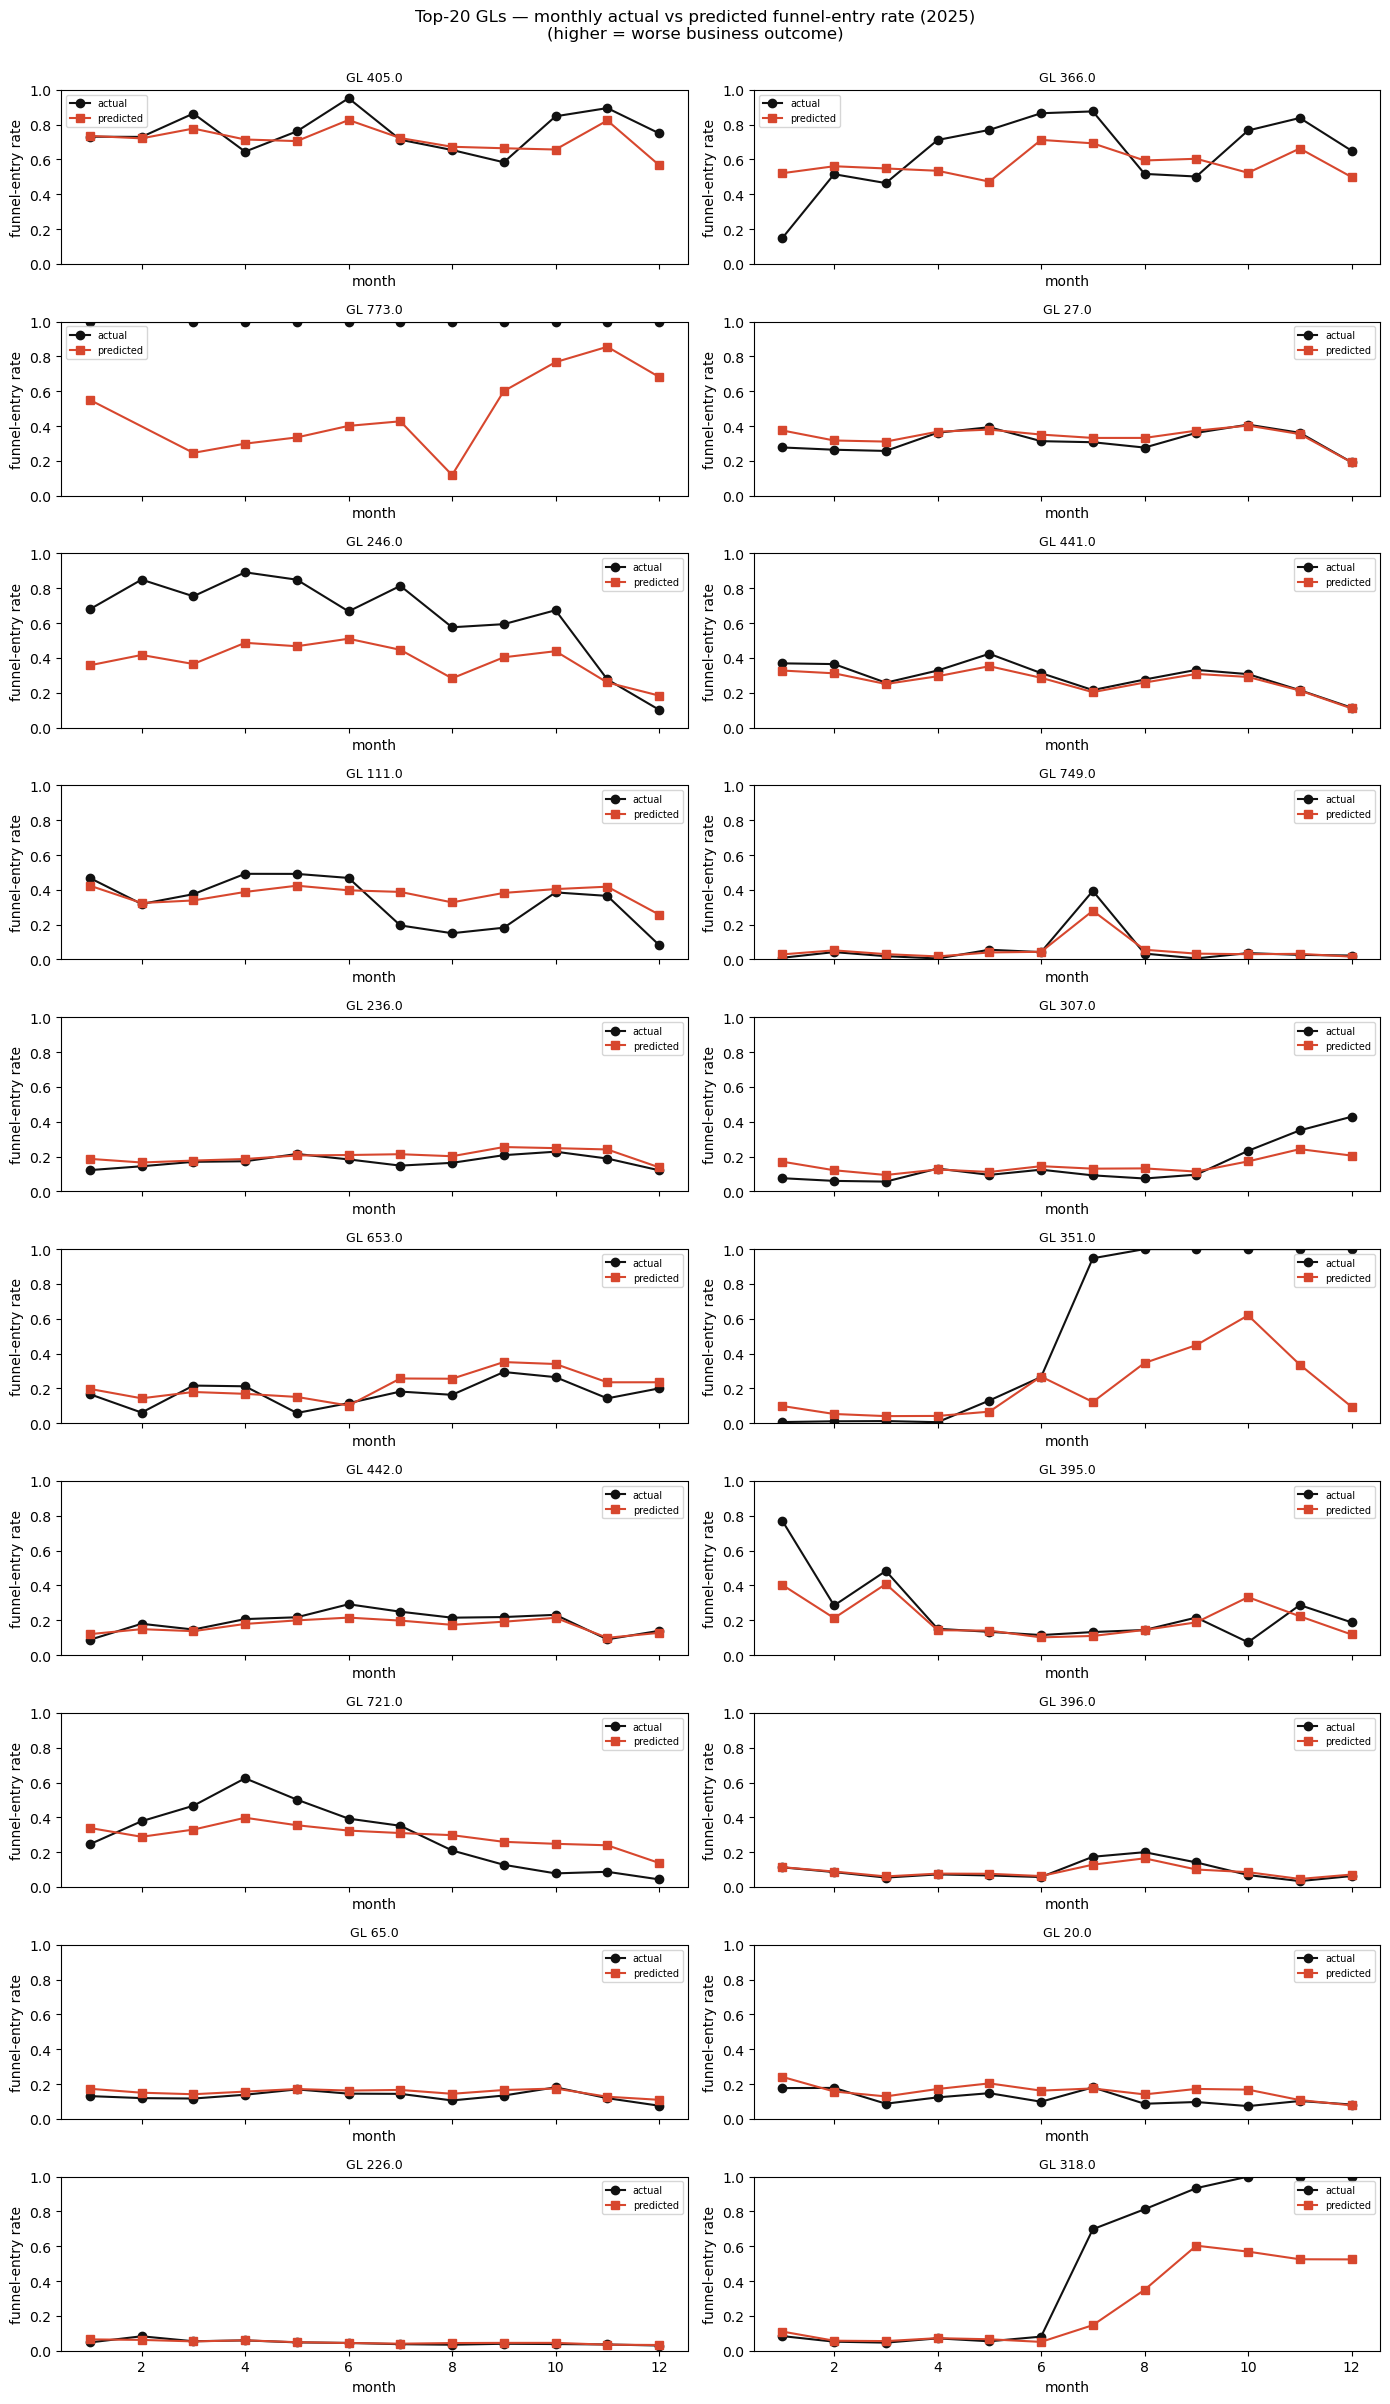

In [55]:
gl_rank = (
    diagnostics
    .group_by("gl_product_group")
    .agg([
        pl.col("units_total").sum().alias("units"),
        ((pl.col("pred_prob") * pl.col("units_total")).sum()
         / pl.col("units_total").sum()).alias("vw_pred"),
    ])
    .filter(pl.col("units") >= MIN_UNITS)
    .sort("vw_pred", descending=True)
    .head(TOP_N)
)
top_gls = gl_rank['gl_product_group'].to_list()
print(f"top {len(top_gls)} GLs (volume-weighted predicted funnel-entry rate — worst performers):")
print(gl_rank)

gl_monthly = (
    diagnostics
    .filter(pl.col("gl_product_group").is_in(top_gls))
    .group_by(["gl_product_group", "month"])
    .agg([
        pl.col("y_true").mean().alias("mean_actual"),
        pl.col("pred_prob").mean().alias("mean_pred"),
        pl.len().alias("n"),
    ])
    .sort(["gl_product_group", "month"])
)

n_cols = 2
n_rows = (len(top_gls) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.4 * n_rows), sharex=True)
axes = axes.flatten()
for ax, gl in zip(axes, top_gls):
    sub = gl_monthly.filter(pl.col("gl_product_group") == gl)
    ax.plot(sub["month"], sub["mean_actual"], color="#111",    marker="o", label="actual")
    ax.plot(sub["month"], sub["mean_pred"],   color="#D7472E", marker="s", label="predicted")
    ax.set_title(f"GL {gl}", fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_xlabel("month"); ax.set_ylabel("funnel-entry rate")
    ax.legend(fontsize=7)
for ax in axes[len(top_gls):]:
    ax.set_visible(False)
plt.suptitle(f"Top-{TOP_N} GLs — monthly actual vs predicted funnel-entry rate (2025)\n(higher = worse business outcome)", y=1.00)
plt.tight_layout(); plt.show()


## Summary

_Fill in once the run completes:_
  - Combined Approach A MAE on 2025: ___
  - Stratified MAE pattern: where does the subset model still struggle?
  - Baseline-vs-deviation: are high-recovery predictions driven by structural site-GL history (baseline) or current-week signals (deviation)? On average and at the tails?
  - Top-site / top-GL panels: which top performers does the model track cleanly, and which show seasonal misses?
